# 1. Exploratory Data Analysis

Here, we are establishing a deeper understanding of the dataset. The aim is to do a simple EDA, looking to understand our data structure, check for class imbalances, check for missing values in key columns (phase, enrollment_count, etc.). Plot distributions of numerical features and counts for categorical features.  Briefly examine the brief_summary and eligibility_criteria.


In [7]:
# load libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [2]:
# Load the complete dataset
dataset = load_dataset("louisbrulenaudet/clinical-trials")

# Access train split
train_data = dataset["train"]

print(f"Dataset size: {len(train_data)}")
print(f"Features: {train_data.features}")

Generating train split:   0%|          | 0/541897 [00:00<?, ? examples/s]

Dataset size: 541897
Features: {'nct_id': Value('string'), 'updated_at': Value('timestamp[us]'), 'brief_title': Value('string'), 'official_title': Value('string'), 'acronym': Value('string'), 'study_type': Value('string'), 'overall_status': Value('string'), 'study_first_submit_date': Value('timestamp[ms]'), 'start_date': Value('timestamp[ms]'), 'primary_completion_date': Value('timestamp[ms]'), 'completion_date': Value('timestamp[ms]'), 'phases': List(Value('string')), 'enrollment_count': Value('float64'), 'minimum_age': Value('float64'), 'maximum_age': Value('float64'), 'sex': Value('string'), 'healthy_volunteers': Value('bool'), 'brief_summary': Value('string'), 'detailed_description': Value('string'), 'eligibility_criteria': Value('string'), 'lead_sponsor_name': Value('string'), 'lead_sponsor_class': Value('string'), 'org_study_id_info': {'id': Value('string'), 'link': Value('string'), 'type': Value('string')}, 'why_stopped': Value('string'), 'expanded_access_info': {'hasExpandedAcc

In [3]:
# convert our dataframe into a pandas dataframe for easier analysis
train_df = train_data.to_pandas()

# Display the first few rows to confirm it worked
print("DataFrame created successfully. Here are the first 5 rows:")
train_df.head()

DataFrame created successfully. Here are the first 5 rows:


,nct_id,updated_at,brief_title,official_title,acronym,study_type,overall_status,study_first_submit_date,start_date,primary_completion_date,...,locations,collaborators,arm_groups,outcomes,overall_officials,study_references,misc_info_module,condition_browse_module,intervention_browse_module,mesh_terms
0,NCT01273766,NaT,Deferasirox in Treating Iron Overload Caused B...,Impact of Intervention With Deferasirox on the...,None,INTERVENTIONAL,COMPLETED,2011-01-07,NaT,NaT,...,"[{'city': 'Winston-Salem', 'country': 'United ...","[{'class': 'NIH', 'name': 'National Cancer Ins...",None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'Wake Forest University Healt...,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D004194', 'term': 'Dise...","{'ancestors': [{'id': 'D007502', 'term': 'Iron...","{'conditions': [{'id': 'D002051', 'term': 'Bur..."
1,NCT00787566,NaT,"Phase 2 Study of Efficacy, Tolerability, and S...","A Randomized, Single Administration, Double-bl...",None,INTERVENTIONAL,COMPLETED,2008-11-05,NaT,NaT,...,[{'city': 'The study is managed by Kendle Inte...,None,None,"{'other': None, 'primary': [{'description': No...",None,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D012817', 'term': 'Sign...","{'ancestors': [{'id': 'D000932', 'term': 'Anti...","{'conditions': [{'id': 'D009325', 'term': 'Nau..."
2,NCT00497666,NaT,Association Between Rosiglitazone Use and Clin...,Retrospective Study Evaluating the Association...,None,OBSERVATIONAL,UNKNOWN,2007-07-06,NaT,NaT,...,"[{'city': 'Zerifin,', 'country': 'Israel', 'fa...",None,None,None,"[{'affiliation': 'Nephrology Division, Assaf H...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D014570', 'term': 'Urol...","{'ancestors': None, 'browseBranches': [{'abbre...","{'conditions': [{'id': 'D007674', 'term': 'Kid..."
3,NCT01978366,NaT,Open Label Extension Study of HT-100 in Patien...,An Open Label Extension Study of HT-100 in Pat...,None,INTERVENTIONAL,TERMINATED,2013-10-31,NaT,2016-04-30,...,"[{'city': 'Sacramento', 'country': 'United Sta...",None,None,"{'other': None, 'primary': [{'description': No...","[{'affiliation': 'AkashiTherapeutics', 'name':...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D020966', 'term': 'Musc...","{'ancestors': [{'id': 'D000970', 'term': 'Anti...","{'conditions': [{'id': 'D009136', 'term': 'Mus..."
4,NCT01971866,NaT,Camera Based System to Monitor Patient Movemen...,Improving Safety and Accuracy of Proton Therap...,DS02,OBSERVATIONAL,TERMINATED,2013-10-17,NaT,NaT,...,"[{'city': 'Jacksonville', 'country': 'United S...",None,None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'University of Florida Proton...,None,"{""versionHolder"": ""2025-06-18""}",None,None,None


### Analyze the Target Variable: overall_status
Our first goal is to understand what we're trying to predict. We need to see all the possible values for overall_status and how often they appear.


Distribution of Clinical Trial Statuses:
overall_status
COMPLETED                    296549
UNKNOWN                       79051
RECRUITING                    66429
TERMINATED                    31493
NOT_YET_RECRUITING            23878
ACTIVE_NOT_RECRUITING         20916
WITHDRAWN                     15333
ENROLLING_BY_INVITATION        4655
SUSPENDED                      1674
WITHHELD                        920
NO_LONGER_AVAILABLE             490
AVAILABLE                       264
APPROVED_FOR_MARKETING          220
TEMPORARILY_NOT_AVAILABLE        25
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_2964\1821292244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")


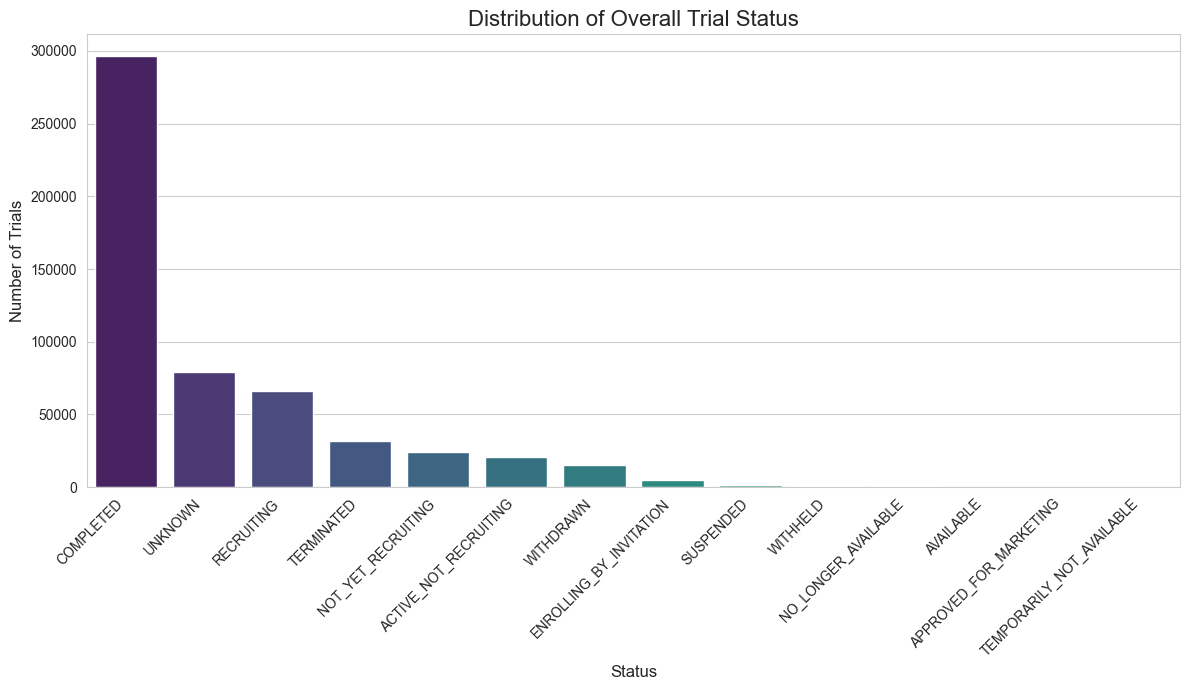

In [4]:
# Set the style for our plots
sns.set_style("whitegrid")

# 1. Get the counts of each status
status_counts = train_df['overall_status'].value_counts()
print("Distribution of Clinical Trial Statuses:")
print(status_counts)

# 2. Visualize the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title('Distribution of Overall Trial Status', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45, ha="right") # Rotate labels for better readability
plt.tight_layout() # Adjust plot to ensure everything fits without overlapping
plt.show()

### Discussion on the classes

Above, you can see all the different classes we have avalable in the "overall_status" column. They are hihgly imbalanced. So now, what I want to do is to simplify this column into a new binary target. 

For our project, we want to predict a clear outcome: Success vs. Failure. A trial that is "Recruiting" hasn't failed yet, so it's not useful for our model. So far, columns that seem like they are stopped for a reason are good targets for "failure", and the "complete" class is good as our "success". 

So, the simplification is: 

- **Success (Target = 1):** We define success strictly as trials marked "COMPLETED".

- **Failure (Target = 0):** We define failure as trials that were stopped due to negative outcomes. We include "TERMINATED" (stopped permanently), "WITHDRAWN" (stopped before enrollment), and "SUSPENDED" (halted due to problems).

We exclude other statuses like "Recruiting" or "Active, not recruiting" as their final outcome is not yet known. This filtering provides us with a clear, unambiguous dataset for training a predictive model.

Original DataFrame size: 541897
Filtered DataFrame size: 345049

Distribution of our new binary target:
target
1    296549
0     48500
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_2964\2282118295.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=filtered_df, palette="coolwarm")


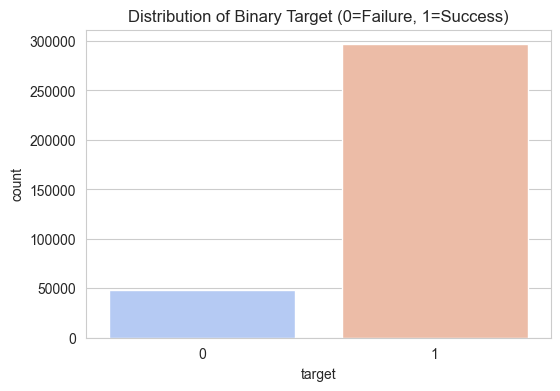

In [5]:
# Define what constitutes success and failure
success_stati = ["COMPLETED"]
failure_stati = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]

# Filter the DataFrame to only include trials with these definitive outcomes
filtered_df = train_df[train_df['overall_status'].isin(success_stati + failure_stati)].copy()

# Create the binary 'target' column
filtered_df['target'] = filtered_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)

# Check the new distribution
print(f"Original DataFrame size: {len(train_df)}")
print(f"Filtered DataFrame size: {len(filtered_df)}")
print("\nDistribution of our new binary target:")
print(filtered_df['target'].value_counts())

# Visualize the new binary target
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=filtered_df, palette="coolwarm")
plt.title('Distribution of Binary Target (0=Failure, 1=Success)')
plt.show()

### Class imbalance thoughts

Even after we create our binary classes, we still have aproxx 1:6 failure to success rate. Right now, I wont be doing anything to "fix" this, however, we will need to address this during the modeling phase using techniques such as downsampling the majority class, oversampling the minority class (e.g., SMOTE), or using class weights in our model's loss function.

### Structured data and feature analysis

Now that we have a clean, well-defined target variable, we should analyze the features we'll use to predict it. We'll focus on finding a few canidates. 

Here are some of my thoughts on some of the different columns, and why they could be important predictors:

**"phases"** 
- This is arguably the strongest predictor in my opinion. Early-phase trials (Phase 1, Phase 2) are designed to be exploratory and have a naturally high failure rate as they test for safety and initial efficacy. Later-phase trials (Phase 3) are much larger and more expensive, and they only happen after a study/drug/trial has shown promise, so they are expected to have a different success rate.

**"study_type"**
- The design of the study is fundamental. An "Interventional" study (where a new drug is tested) is inherently riskier and more prone to failure than an "Observational" study (where researchers just observe outcomes without intervention).

**"enrollment_count"**
- This represents the size and ambition of a trial. A very low enrollment target might indicate a small, exploratory study. A very high target is typical of a Phase 3 trial. Difficulty in recruiting the target number of patients is also a major reason for trial termination, so this number is a key indicator of operational complexity.

**"'lead_sponsor_class'"**
- The organization funding the trial is critical. A large pharmaceutical company ("Industry") has different resources, motivations, and processes than an academic university ("Academia") or a government body ("NIH"). We could also then hypothesize that industry-sponsored trials might have different success patterns than academic ones, and we will likely group these into classes.

**"sex"** 
- This defines the target population. Trials targeting "All" participants may be easier to recruit for than those targeting only "Male" or "Female." This can also be an indicator for specific types of diseases (e.g., prostate vs. ovarian cancer) which may have different research challenges.

**"minimum_age" / "maximum_age"**
- These features also define the target population. Trials involving vulnerable populations, like children (pediatric) or the elderly (geriatric), can face more complex ethical and medical challenges, potentially leading to higher rates of suspension or termination. These fields tell us about the complexity of the patient cohort. Note: These are often text fields (e.g., "18 Years") and will need cleaning.

In [6]:
# checking for missing values
# Use the DataFrame that was filtered and has the binary target
df_for_eda = filtered_df.copy()

# Select a subset of promising structured features to analyze
# Using corrected names from the Hugging Face schema
structured_features = [
    'phases', 'study_type', 'enrollment_count', 
    'lead_sponsor_class', 'sex', 'minimum_age', 'maximum_age'
]

# Check for missing values in these key columns
missing_values = df_for_eda[structured_features].isnull().sum()

print("Missing values in key structured features:")
# We'll print the percentage of missing values for better context
missing_percentage = (missing_values / len(df_for_eda)) * 100
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

Missing values in key structured features:
maximum_age         46.706700
phases              20.687786
minimum_age          6.537622
enrollment_count     1.242142
sex                  0.088973
dtype: float64


### What to do with the missing data? 

The output we got above shows the different % of missing data in our chosen columns. Most models dont handle missing data, so we need to clean our data. 

Depending on how much data is missing, we have some different options on what to do. 

| Missing Percentage | Severity  | Our Strategy                                                                                                                                       |
|--------------------|-----------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| < 2-3%             | Low       | The problem is tiny. The easiest and cleanest solution is to simply **drop the few rows** that have these missing values. We won't lose much data. |
| 3% - 50%           | Moderate  | Dropping is too risky; we'd throw away too much valuable data. We need to intelligently **fill in the gaps (impute)**.                           |
| > 50%              | High      | The column is mostly empty and potentially useless. We might consider **dropping the entire column**, as it doesn't contain much information.    |


Based on our output, here is our action plan:

1. sex (0.08%) and enrollment_count (1.24%):
    - Problem: Tiny amount missing.

    - Decision: We will drop the rows where these values are missing. It's the simplest and best solution.

2. phases (20.7%) and minimum_age (6.5%):
    - Problem: Moderate amount missing.

    - Decision: We must impute (fill in) these values.

        - For phases, we can treat "missing" as its own category, like "Unknown". This is often a good strategy for categorical data.

        - For minimum_age, we could fill the missing values with the median age of the dataset.

3. maximum_age (46.7%):

    - Problem: High amount missing. This is a tricky one.

    - Decision: Dropping the column would be a loss of potentially useful information. A better approach for now is to also impute it, but we need to be careful. We could fill it with the median, or perhaps a very high number like "100" to signify no upper age limit. We also need to clean the age columns, as they are likely text (e.g., "18 Years").

### distributions of categorical features


Analyzing the 'phases' column...


C:\Users\esthe\AppData\Local\Temp\ipykernel_2964\2837903822.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='plasma')


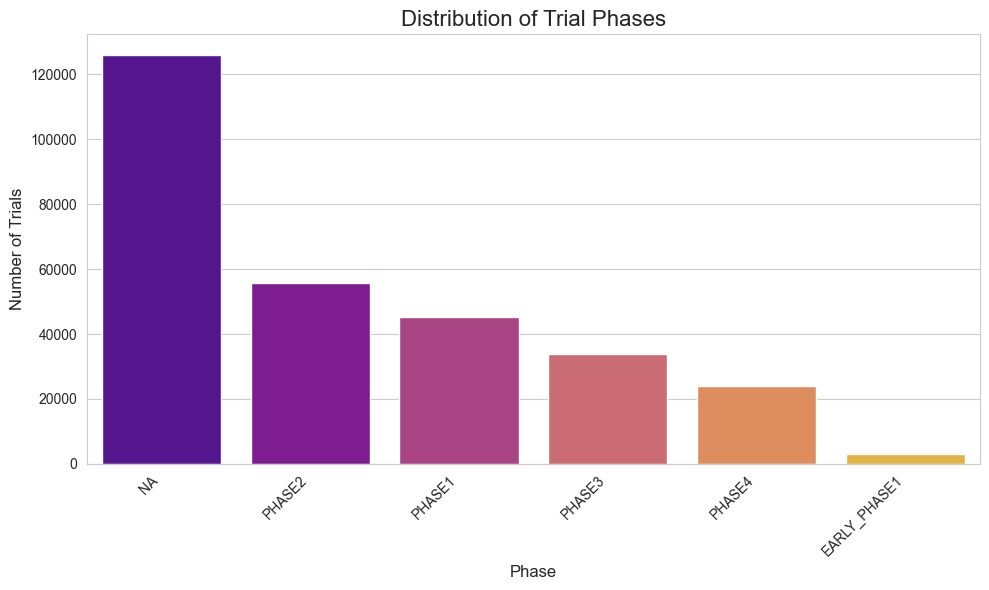

C:\Users\esthe\AppData\Local\Temp\ipykernel_2964\2837903822.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df_for_eda, ax=axes[i], palette='viridis', order=df_for_eda[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_2964\2837903822.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df_for_eda, ax=axes[i], palette='viridis', order=df_for_eda[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_2964\2837903822.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn

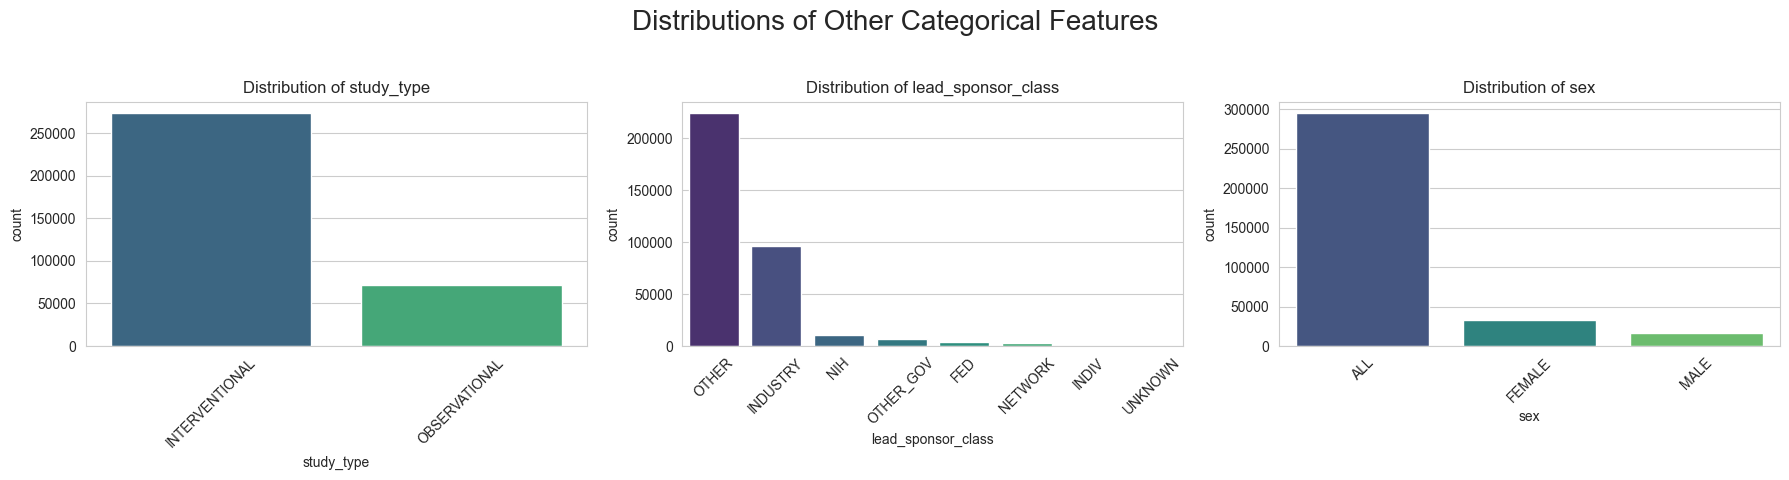

In [7]:
# --- 1. Correctly analyze and plot the 'phases' column ---
print("Analyzing the 'phases' column...")

# Explode the series to get one row per phase, and then get the value counts.
# This is fast and handles the array/list structure correctly.
phase_counts = df_for_eda['phases'].explode().value_counts()

# Now, create a bar plot of the pre-calculated counts
plt.figure(figsize=(10, 6))
sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='plasma')
plt.title('Distribution of Trial Phases', fontsize=16)
plt.xlabel('Phase', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- 2. Plot the other categorical features ---

simple_categorical_features = ['study_type', 'lead_sponsor_class', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Other Categorical Features', fontsize=20)
axes = axes.flatten()

for i, feature in enumerate(simple_categorical_features):
    # This code works because the data it's plotting doesn't have the duplicate index issue
    sns.countplot(x=feature, data=df_for_eda, ax=axes[i], palette='viridis', order=df_for_eda[feature].value_counts().index)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Plot analysis: 

**Looking at the "phases" plot**, we not see a huge category labeled "NA". Here we have to remember that our erlier aproxx. 20% missing data we saw, was cells with no data(NaN), meanwhile the NA is filled in by the creators of the data, intentionally. This can be for different reasons, for example if the trial does not have phases. For example, an "Observational" study doesn't have a clinical "phase," so its phase is correctly "Not Applicable.". This means that we can treat "NA" as a distinct category that our model can learn from. Our hypothesis might be that trials with phase "NA" (likely observational) have a very different success rate than interventional Phase 3 trials. 

**Looking at the "lead_sponsor_class" plot**, we can see a long tail distribution, where most of the data is labelled as "OTHER". This is not very infromative. For now, I will treat this as its own single category. I will just aknowledge this a s a data limitation for now, in P2. It can still be a useful feature if trials sponsored by "INDUSTRY" or "NIH" have a different success rate than "OTHER". 

However, when we have moved into P3, we could, if we wanted to improve the model, perform a sub-analysis on the lead_sponsor_name column for all trials where lead_sponsor_class is "OTHER". We could find the top 5 most common sponsors within "OTHER" and create new categories for them, leaving the rest in a smaller "OTHER" bucket.

**Looking at the "study_type" plot**, we see that most of the trials are "INTERVENTIONAL". This is a reflection of reality. This is still a very powerful feature. Our model will almost certainly learn that interventional studies have a different failure rate than observational ones.

**Looking at the "sex" plot**, we see that an overwhelming majority of studyies accept both genders. The model can learn from this. The MALE vs FEMALE ratio is also interesting, and the model might find patterns there for specific conditions.

### distributions of numerical features

To start out, ill chekc if my numerical columns are truly numerical. I am mainly doing this because I want to make sure that the two age columns are actually numerical, because datasets will often include pseudo numerical values, where instead of having 25 as a number, we will have "25" or "25 years" as a string. But we just need to chek them to make sure beofre we move on. 


In [8]:
# List of our potential numerical features
numerical_features_to_check = ['enrollment_count', 'minimum_age', 'maximum_age']

# Check the data type of each column
print("Data types of potential numerical features:")
print(df_for_eda[numerical_features_to_check].dtypes)

Data types of potential numerical features:
enrollment_count    float64
minimum_age         float64
maximum_age         float64
dtype: object


Here, I will look at summary statistics. This is because I want to get some ideas on the distributions before I plot them so that I can chose the best visalization. 

The pandas.describe() method is my primary tool here. It gives me the count, mean, standard deviation, min, max, and quartile values. The key to detecting skew is to compare the mean and the median (the 50% mark). The Rule of Thumb:
- If the mean is much larger than the median, the data is right-skewed. This means there is a "tail" of very high values pulling the average up.
- If the mean is much smaller than the median, the data is left-skewed.
- If the mean and median are very close, the data is likely symmetrical (like a bell curve).

In [9]:
# Our confirmed list of numerical features
numerical_features = ['enrollment_count', 'minimum_age', 'maximum_age']

# Generate summary statistics for all numerical columns at once
summary_stats = df_for_eda[numerical_features].describe()

print("Summary statistics for all numerical features:")
summary_stats

Summary statistics for all numerical features:


,enrollment_count,minimum_age,maximum_age
count,3.407630e+05,322491.000000,183888.000000
mean,4.124893e+03,20.080337,58.631335
std,3.981039e+05,11.267044,31.160500
min,0.000000e+00,0.000000,1.000000
25%,2.400000e+01,18.000000,45.000000
50%,6.000000e+01,18.000000,65.000000
75%,1.590000e+02,18.000000,75.000000
max,1.888141e+08,730.000000,6569.000000


For the "enrollment_count" column, we see a massive, extreme right skew. The mean is almost 70 times larger than the median. This tells us that while the "typical" trial has around 60 participants, there are a few gigantic "mega-trials" with millions of participants that are dragging the average way up.

For "maximum_age", the mean (58.6) is a bit smaller than the median (65). This suggests a slight left skew, meaning there's a tail of studies with unusually low maximum ages. However what us strange about it is that we have a min of 1, in a maximum column, which is a bit strange. It might have something to do with infanry studies, but thats something we need further analysis for. The max value of this column is also 6569, which I hope is a data entry error. 

For "minimum_age", the mean (20.08) is slightly larger than the median (18). This is a slight right skew, but much less dramatic than the enrollment count. This column has a min of 0, which is plausable. It could represent studies on newborns where age is measured in days/weeks, but recorded as 0 years. However, the max value of this column is 730. It's impossible for a study to have a minimum age of 730.

So, what we have found out is:
1. All three numerical features are heavily skewed.
2. The age columns contain clear data entry errors/outliers.

This provides us with a data-driven justification for our next step: visualization. We now know that simply plotting a standard histogram will be unreadable. We must use a log scale to handle the skew we've just proven exists with these statistics.

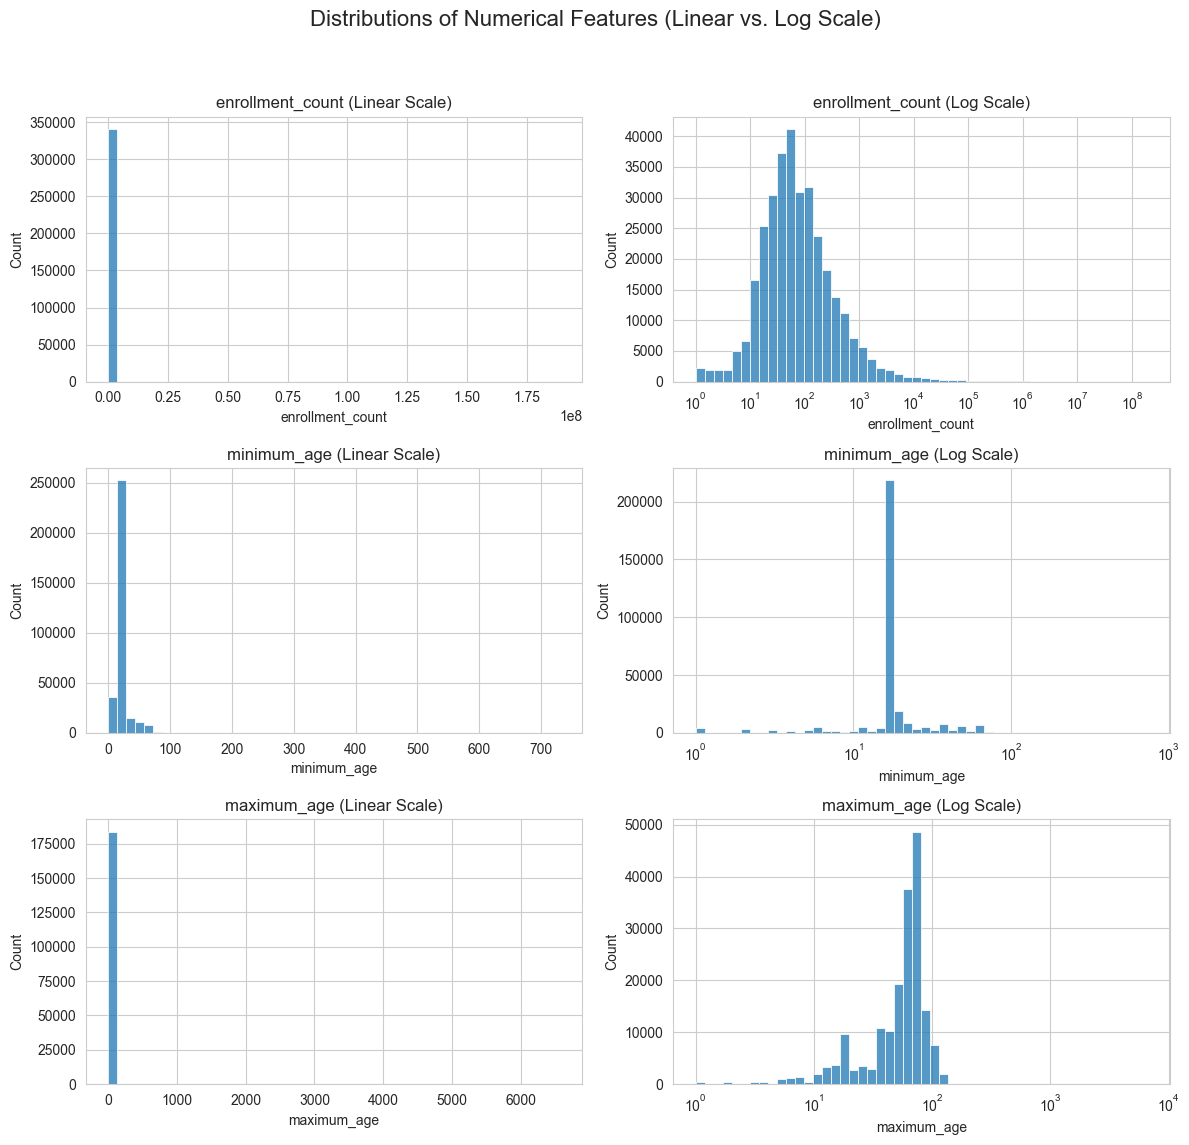

In [10]:
# Our final list of numerical features
numerical_features = ['enrollment_count', 'minimum_age', 'maximum_age'] # Assuming you kept these new names

# Create plots for each numerical feature
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 12))
fig.suptitle('Distributions of Numerical Features (Linear vs. Log Scale)', fontsize=16)

for i, feature in enumerate(numerical_features):
    # Plot on a linear scale
    sns.histplot(df_for_eda[feature], bins=50, kde=False, ax=axes[i, 0])
    axes[i, 0].set_title(f'{feature} (Linear Scale)')
    
    # Plot on a log scale
    sns.histplot(df_for_eda[feature], bins=50, kde=False, ax=axes[i, 1], log_scale=True)
    axes[i, 1].set_title(f'{feature} (Log Scale)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Analysis of the histograms

1. `enrollment_count`

- **Linear Scale (Left):** This plot is a perfect visual of the "extreme right skew" we saw in the stats. Almost all the data (300,000+ trials) is crushed into the very first bin on the left, and we can't see any detail. This plot is practically unreadable.

- **Log Scale (Right):** This plot is more informative. The log scale has revealed the true shape of the distribution. It's no longer a spike; it looks much more like a "bell curve" (a classic log-normal distribution). We can now clearly see that the most common trial size is centered between `10^1` and `10^2`, which is **10 to 100 participants**. This perfectly matches the median of 60 we saw earlier.



2. `minimum_age`

- **Linear Scale (Left):** This plot is actually quite informative, more so than the log version. It clearly shows a **massive, dominant spike at a single value** (which we know from our stats is 18). There's another smaller spike at 0, and very little else.

- **Log Scale (Right):** This plot is **very hard to read**. The log scale is trying to stretch an axis where most of the data is concentrated in an extremely narrow band. This creates the giant, thin spike at 18 (which is just after `10^1`). The log scale is the **wrong visualization tool** for this specific feature because the feature doesn't span many orders of magnitude.

- **Conclusion:** `minimum_age` doesn't behave like a true continuous variable. It acts more like a **categorical feature** where the overwhelming majority of trials have a `minimum_age` of **18**. 


3. `maximum_age`

- **Linear Scale (Left):** Like the first plot, this is a visual showing a typical "extreme right skew". Almost all the data is crushed into the very first bin on the left, and we can't see any detail.

- **Log Scale (Right):** This plot is more helpful than the linear one. It shows the distribution is centered around `10^1` to `10^2` (10 to 100 years). We know the median is 65, which fits perfectly in the middle of that big central peak. We can see the shape of the main cluster much more clearly than on the linear scale.

- **Conclusion:** The `maximum_age` is also right-skewed, and the log transform helps to visualize its central tendency. The typical maximum age for a trial is around **65**.


**Over all conclusion:**
1. `enrollment_count` is a classic log-normal feature.  

2. `minimum_age` is a "degenerate" numerical feature that acts more like a categorical one, with a huge spike at 18.  

3. `maximum_age` is a more standard, continuous skewed feature where the typical value is around 65.  


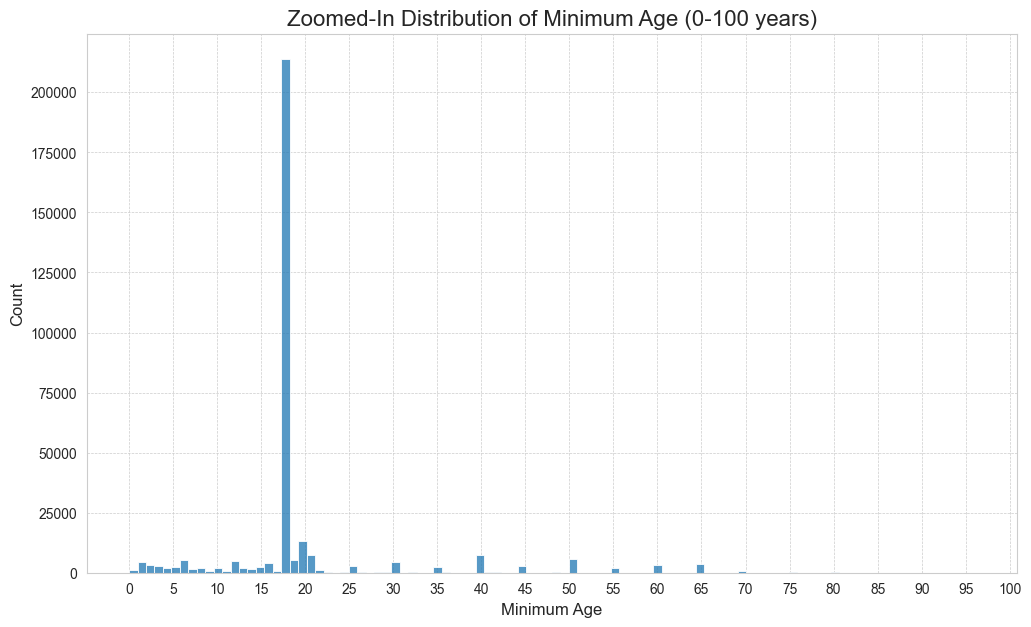

In [11]:
# Create a filtered view of the data for plotting, excluding extreme outliers
zoomed_df = df_for_eda[df_for_eda['minimum_age'] <= 100]

# Now, create a new histogram with this filtered data
plt.figure(figsize=(12, 7))
sns.histplot(data=zoomed_df, x='minimum_age', bins=100) # Using more bins for more detail
plt.title('Zoomed-In Distribution of Minimum Age (0-100 years)', fontsize=16)
plt.xlabel('Minimum Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=range(0, 101, 5)) # Add ticks every 5 years for clarity
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

looking at a zoomed in view of the minimum age distribution, we can see that we have many different ages listed, however, it is dominated by thwe 18 year old age group. Which makes sense. We have a somewhat considtent distribution for individuals under 18, but as we increse in age, we start seeing bigger gaps in our histogram. We see definate bins at adult ages such as 40, 45, 50 ect, which is probably due to research stating that the difference ebtween lets say 40 and 42 is meaningless, however the difference between 12 and 15 or 15 and 17 is often more interesting/ significant. 

However, this is very important for our model later on., We cant really treat this column as a simple number, because if we do, our model might learn weird or incorrect relationships. For example, it might learn that a minimum age of 60 is 3.33 times more predictive than an age of 18, which would be nonsense. The relationship here isnt linear. 

For p2, we can argue that since we are focusing on proof-of-concept, we can keep this column numerical. But when we move to p3, we should look into how to not use the raw numbers here, potentially building a new column called "age_category" or something similar. It could include categorical age pools like "pedritric" (under 18 year olds), "young_adult", "mid_life" and "senior". However this requers some assumtions and/or data supporting which ages should be in which category. 

#  Training our own embeddings

Even though the documentation for the dataset promises a fully enriched dataset with pretrained embeddings, the dataset itself actually does not incldue this. So our aim is to train the embeddings ourselves. We do this on google colab, so that we can use a GPU. We start by creating a subset of a 140.000 rows. The notebook used on colab is: "subset-embedding-training.ipynb", if you are itnerested in the code used. From there we download the new dataset, and are able to start modelling. 

# Load the new enriched dataset and create splits

Here we load the dataset we enriched. Remember to store the dataset in the same working directory or change the file path

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- 1. Load the Pre-Processed Data from Parquet File ---
print("Loading the subset dataset with our trained embeddings from Parquet file...")
# This is much faster than loading a CSV.
subset_df_with_embeddings = pd.read_parquet('subset_dataset_with_embeddings.parquet')
print("Dataset loaded.")
print("Columns:", subset_df_with_embeddings.columns)

# --- 2. Create the Train/Test Split ---
# This step is now very fast because the heavy work is done.
raw_train_df, raw_test_df = train_test_split(
    subset_df_with_embeddings,
    test_size=0.2,
    random_state=42,
    stratify=subset_df_with_embeddings['overall_status']
)

Loading the subset dataset with our trained embeddings from Parquet file...
Dataset loaded.
Columns: Index(['nct_id', 'updated_at', 'brief_title', 'official_title', 'acronym',
       'study_type', 'overall_status', 'study_first_submit_date', 'start_date',
       'primary_completion_date', 'completion_date', 'phases',
       'enrollment_count', 'minimum_age', 'maximum_age', 'sex',
       'healthy_volunteers', 'brief_summary', 'detailed_description',
       'eligibility_criteria', 'lead_sponsor_name', 'lead_sponsor_class',
       'org_study_id_info', 'why_stopped', 'expanded_access_info',
       'last_update_submit_qc_date', 'last_update_post_date_struct',
       'study_first_post_date_struct', 'std_ages', 'study_population',
       'sampling_method', 'oversight_has_dmc', 'design_info', 'conditions',
       'keywords', 'interventions', 'locations', 'collaborators', 'arm_groups',
       'outcomes', 'overall_officials', 'study_references', 'misc_info_module',
       'condition_browse_modul

## 2. Data Preprocessing and Pipeline

Based on the findings from our Exploratory Data Analysis, we need to perform several preprocessing steps to prepare the data for our baseline machine learning model. Our goal is to create a clean, purely numerical feature matrix `X` and a target vector `y`.

We will encapsulate this entire process into a single, reusable function. Here is the plan for our data handling pipeline:

**Pipeline Steps:**

0.  **Split the dataset into a train and a test split** 


1.  **Select Final Features:** We will start with the subset of structured features we analyzed: `phases`, `study_type`, `enrollment_count`, `lead_sponsor_class`, `sex`, `minimum_age`, and `maximum_age`.

2.  **Create Binary Target:** We will use the binary `target` column we created earlier (1 for Success, 0 for Failure).

3.  **Handle Missing Values:** Based on our EDA, we will apply the following strategies:
    *   **Drop Rows:** For `sex` and `enrollment_count`, where less than 2% of data is missing, we will drop the corresponding rows. This is the cleanest approach for small amounts of missing data.
    *   **Impute Categorical:** For `phases`, we will fill missing (`NaN`) values with the string `"Unknown"`. This treats "missingness" as its own category.
    *   **Impute Numerical:** For `minimum_age` and `maximum_age`, we will fill missing (`NaN`) values with the **median** of each respective column. The median is a robust choice given the skewness and outliers we observed.

4.  **Encode Categorical Features:** Machine learning models require numerical input. We will convert our categorical columns (`phases`, `study_type`, `lead_sponsor_class`, `sex`) into a numerical format using **One-Hot Encoding**. This creates a new binary column for each category and avoids implying an incorrect ordinal relationship.

5.  **Scale Numerical Features:** The numerical features (`enrollment_count`, `minimum_age`, `maximum_age`) have vastly different scales. To prevent features with large values from dominating the model, we will scale them using a **StandardScaler**, which will give each feature a mean of 0 and a standard deviation of 1.

6.  **Final Output:** The pipeline will return a final, processed DataFrame ready for modeling.

In [2]:
# Import train_test_split from scikit-learn 
from sklearn.model_selection import train_test_split


# --- SPLIT THE RAW DATA FIRST ---
# We'll use 80% for training and 20% for testing.
# stratify=full_df['overall_status'] is important for classification. It ensures that the
# proportion of each status category is the same in both the train and test sets.
raw_train_df, raw_test_df = train_test_split(
    subset_df_with_embeddings, 
    test_size=0.2, 
    random_state=42, # for reproducibility
    stratify=subset_df_with_embeddings['overall_status']
)

print(f"Full dataset size: {len(subset_df_with_embeddings)}")
print(f"Raw training set size: {len(raw_train_df)}")
print(f"Raw testing set size: {len(raw_test_df)}")

Full dataset size: 140000
Raw training set size: 112000
Raw testing set size: 28000


### make subset transofrmation rules to prevent data leakage

In [3]:
from utils import fit_and_preprocess_train, transform_test_data
import numpy as np
# This will generate NEW rules based on the subset's training data
processed_train_df, new_transformation_rules = fit_and_preprocess_train(raw_train_df)

# This will apply those NEW rules to the subset's test data
processed_test_df = transform_test_data(raw_test_df, new_transformation_rules)

# Inspect the final, processed DataFrames
print("\nProcessed Training Data Head:")
display(processed_train_df.head())

print("\nProcessed Testing Data Head:")
display(processed_test_df.head())

Dropped 950 rows with missing 'sex' or 'enrollment_count'.
Training data preprocessed successfully according to the specific plan.
Test data transformed successfully using training set rules.

Processed Training Data Head:


,enrollment_count,minimum_age,maximum_age,phases_EARLY_PHASE1,phases_NA,phases_PHASE1,phases_PHASE2,phases_PHASE3,phases_PHASE4,phases_Unknown,...,lead_sponsor_class_INDUSTRY,lead_sponsor_class_NETWORK,lead_sponsor_class_NIH,lead_sponsor_class_OTHER,lead_sponsor_class_OTHER_GOV,lead_sponsor_class_UNKNOWN,sex_ALL,sex_FEMALE,sex_MALE,target
76856,-0.014037,-0.176784,-2.009521,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3206,-0.014854,-0.176784,0.152953,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
73216,-0.011256,2.771167,0.152953,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1259,-0.015098,-0.084661,0.152953,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
120625,-0.014810,-0.729525,0.468314,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1



Processed Testing Data Head:


,enrollment_count,minimum_age,maximum_age,phases_EARLY_PHASE1,phases_NA,phases_PHASE1,phases_PHASE2,phases_PHASE3,phases_PHASE4,phases_Unknown,...,lead_sponsor_class_INDUSTRY,lead_sponsor_class_NETWORK,lead_sponsor_class_NIH,lead_sponsor_class_OTHER,lead_sponsor_class_OTHER_GOV,lead_sponsor_class_UNKNOWN,sex_ALL,sex_FEMALE,sex_MALE,target
42718,-0.014967,-0.176784,0.152953,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1
88153,-0.014609,-0.176784,0.152953,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
29720,-0.014958,-0.176784,0.378211,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
67271,-0.014797,-0.176784,0.152953,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
103969,-0.015085,-0.176784,0.152953,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1


### thoughts on which model to use as our structured data baseline

we are doing classic binary classification on structured tabular data, which opens up the doors for the following models: 

Excellent questions. This is the fun part where we start making modeling decisions. You're right to think about which model to choose and how thorough we need to be.

1.  **Logistic Regression:**
    *   **How it works:** It's a simple, linear model. It learns a single weight for each feature and passes the result through a logistic function to get a probability between 0 and 1.
    *   **Pros:** Very fast to train, highly interpretable (you can look at the weights to see which features the model thinks are important).
    *   **Cons:** It's a linear model, so it can't capture complex, non-linear relationships between features. For example, it can't learn that a trial with `phase_PHASE2` AND `lead_sponsor_class_INDUSTRY` is much more likely to succeed than if those two features appeared separately.

2.  **Random Forest Classifier:**
    *   **How it works:** This is an "ensemble" model. It builds hundreds of individual decision trees, each trained on a random subset of the data and features. To make a prediction, it takes a "vote" from all the trees.
    *   **Pros:** Very powerful. It can easily learn complex, non-linear relationships. It's also quite robust to outliers and doesn't require as much feature scaling (though it's still good practice). Crucially, it provides **feature importances**, which is a great way to get insights.
    *   **Cons:** Can be slower to train than Logistic Regression. The individual trees are complex, making the model a bit of a "black box," although feature importances help a lot.

3.  **Gradient Boosting Machines (like XGBoost, LightGBM, or CatBoost):**
    *   **How it works:** This is another, more advanced ensemble of decision trees. Instead of building trees independently, it builds them sequentially. Each new tree is trained to correct the mistakes of the previous one.
    *   **Pros:** Often the highest-performing models on tabular data.
    *   **Cons:** Can be even slower to train and have more "hyperparameters" to tune, making them more complex to set up.

Since this is our baseline we are building, the RandomForestClassifier is a solud choice. It is powerful enpugh to be a good baseline, its easy to implement, and its feature importance plot makes a lot of sense for a "proof of concept" milestone. Using a strong non-linear model thats not too hard to set up or train works well here. We could look into, if time allows for P3, to also train the gradient boosting machines or even our own ensable for a better baseline, but that is a bit on the backburner, at least for now. 

## 3. Baseline Model (Proof of Concept)

With our data preprocessed, we can now build our baseline model. The goal is to establish a benchmark performance using only the structured metadata.

For our baseline, we will use a **Random Forest Classifier**. This is a powerful and interpretable ensemble model that can capture non-linear relationships in the data, making it a strong choice for a robust baseline.

In [4]:
# Import the necessary model and metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# --- Prepare Data for Model ---
# We already have our processed_train_df and processed_test_df.
# Now we separate them into features (X) and target (y).
X_train = processed_train_df.drop('target', axis=1)
y_train = processed_train_df['target']

X_test = processed_test_df.drop('target', axis=1)
y_test = processed_test_df['target']

# Sanity check the shapes of our final datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (70399, 23)
Shape of y_train: (70399,)
Shape of X_test: (17588, 23)
Shape of y_test: (17588,)


In [5]:
# --- Train the Random Forest Model ---

# Initialize the classifier
# n_estimators=100 is a good default number of trees.
# random_state=42 ensures that the model will produce the exact same results every time we run it.
# n_jobs=-1 tells the model to use all available CPU cores, which can significantly speed up training.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data
print("Training the Random Forest model...")
rf_classifier.fit(X_train, y_train)
print("Training complete.")

# --- Make Predictions on the Test Data ---
print("\nMaking predictions on the test set...")
y_pred = rf_classifier.predict(X_test)
print("Predictions complete.")

Training the Random Forest model...
Training complete.

Making predictions on the test set...
Predictions complete.


--- Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.69      0.48      0.57      2498
 Success (1)       0.92      0.97      0.94     15090

    accuracy                           0.90     17588
   macro avg       0.81      0.72      0.75     17588
weighted avg       0.89      0.90      0.89     17588


--- Confusion Matrix ---


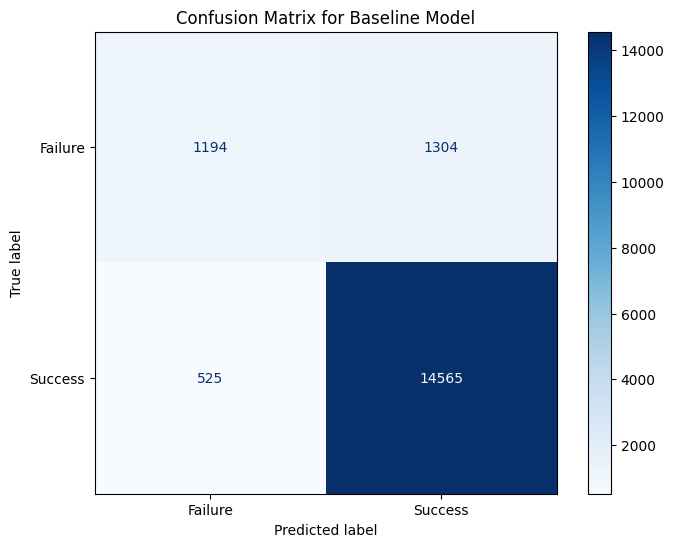

In [8]:
# --- Evaluate the Model's Performance ---

# 1. Print the Classification Report
print("--- Classification Report ---")
# The 'target_names' parameter makes the report easier to read.
report = classification_report(y_test, y_pred, target_names=['Failure (0)', 'Success (1)'])
print(report)

# --- Confusion Matrix ---
print("\n--- Confusion Matrix ---")
# Temporarily reset the style to default to fix the gridline issue
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Blues'
    )
    plt.title("Confusion Matrix for Baseline Model")
    plt.show()

# The style will automatically revert to 'whitegrid' after the 'with' block

### Analysis of the Baseline Model Performance (on Subset)

The Random Forest baseline model was trained and evaluated on the preprocessed structured data from our 140,000-row subset. The results, summarized in the classification report and confusion matrix, establish a clear performance benchmark and highlight the significant impact of the dataset's class imbalance.

**Overall Performance:**
The model achieves a high overall **accuracy of 90%**. However, as anticipated from our EDA, this number is misleadingly optimistic. It is heavily inflated by the model's strong performance on the dominant "Success" class, which makes up the vast majority of the test set (`support` of 15,090 vs. 2,498). The `weighted avg f1-score` of **0.89** also reflects this bias. A more telling metric is the `macro avg f1-score`, which is **0.75**, indicating a more moderate overall performance when both classes are treated equally.

**Performance on the "Success" Class (Majority Class):**
The model is highly effective at identifying successful trials.
*   **Recall (0.97):** It correctly identifies 97% of all actual "Success" cases. From the confusion matrix, we see it correctly classified **14,565** successful trials while only missing **525** (False Negatives).
*   **Precision (0.92):** When it predicts "Success," it is correct 92% of the time.
*   **F1-Score (0.94):** The high F1-score confirms the model's proficiency and confidence in predicting the majority class, which is expected given the large volume of training examples.

**Performance on the "Failure" Class (Minority Class):**
This is where the model's primary weakness is evident, directly confirming our hypothesis about the class imbalance.
*   **Recall (0.48):** This is the most critical result. The model only manages to identify **48%** of all actual "Failure" cases. The confusion matrix shows that while it correctly found **1,194** failures (True Negatives), it incorrectly classified **1,304** failures as successes (False Positives). The model is **missing more than half of the failed trials.**
*   **Precision (0.69):** The precision is respectable, meaning that when it does predict "Failure," it's correct 69% of the time.
*   **F1-Score (0.57):** This low F1-score is a direct consequence of the poor recall and serves as our key performance benchmark for the minority class.

**Conclusion for Baseline Model:**
This proof of concept is successful. We have a working end-to-end pipeline and a clear benchmark. The model has learned to identify successful trials but is heavily biased towards this majority class, leading to poor performance in identifying the rarer but often more critical "Failure" cases. This result strongly justifies the need for more advanced techniques in P3, such as **class weighting or resampling strategies (like downsampling)**, to create a more balanced and useful predictive model.

## 4. Embeddings Model (Initial Version)

As per our advisor's feedback, we will now build a tentative baseline model using only the pre-computed text embeddings. The goal is to establish a second proof of concept to see how well the semantic information from the trial summaries can predict success on its own.

When trying to load what the creators of the dataset claim are already enhanced embedding columns, we found that the pre-computed embeddings mentioned in the dataset description are not included in the default download. As per the author's provided code, the intended workflow is to generate these embeddings ourselves we think, since they do include code to train your own embeddings. We (as seen above) trained enmbeddings for a subset of the dataset to act as our tentative data for the proof-of-concept. 


### Model discussions

Since this is a tentative version, or a baseline model on text embeddings, the goal is a model that is fast, simple, and known to work well with high-dimensional, dense data. For these reasons we have chosen logistic regression as our baseline. 

In [10]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Prepare Data for Embeddings Model ---

# Define our definitive outcomes
success_stati = ["COMPLETED"]
failure_stati = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]
definitive_stati = success_stati + failure_stati

# --- CORRECTED: Filter the raw dataframes FIRST ---
# This ensures we are only working with trials that have a clear success or failure outcome.
# This step mirrors the filtering done inside the fit_and_preprocess_train function.
train_emb_df = raw_train_df[raw_train_df['overall_status'].isin(definitive_stati)].copy()
test_emb_df = raw_test_df[raw_test_df['overall_status'].isin(definitive_stati)].copy()

# Now, create the 'target' column on these smaller, filtered dataframes
train_emb_df['target'] = train_emb_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)
test_emb_df['target'] = test_emb_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)

# Extract the two embedding columns from the FILTERED training data
X_train_emb_summary = np.vstack(train_emb_df['brief_summary_embedding'].values)
X_train_emb_criteria = np.vstack(train_emb_df['eligibility_criteria_embedding'].values)
# Concatenate them to create the final feature matrix
X_train_emb_np = np.concatenate([X_train_emb_summary, X_train_emb_criteria], axis=1)

# Extract the target variable for training
y_train_emb = train_emb_df['target'].values

# Do the same for the FILTERED test data
X_test_emb_summary = np.vstack(test_emb_df['brief_summary_embedding'].values)
X_test_emb_criteria = np.vstack(test_emb_df['eligibility_criteria_embedding'].values)
X_test_emb_np = np.concatenate([X_test_emb_summary, X_test_emb_criteria], axis=1)

y_test_emb = test_emb_df['target'].values

# --- Sanity Checks ---
print(f"Shape of filtered training embeddings matrix (X_train_emb_np): {X_train_emb_np.shape}")
print(f"Shape of filtered testing embeddings matrix (X_test_emb_np): {X_test_emb_np.shape}")

Shape of filtered training embeddings matrix (X_train_emb_np): (71349, 1536)
Shape of filtered testing embeddings matrix (X_test_emb_np): (17836, 1536)


In [11]:
# --- 2. Train the Logistic Regression Model ---

# Initialize the classifier
# max_iter=1000 is a good idea for larger datasets to ensure the model converges.
lr_classifier = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)

# Train the model on the embeddings data
print("Training the Logistic Regression model on embeddings...")
lr_classifier.fit(X_train_emb_np, y_train_emb)
print("Training complete.")

# --- 3. Make Predictions ---
print("\nMaking predictions on the test set...")
y_pred_emb = lr_classifier.predict(X_test_emb_np)
print("Predictions complete.")

Training the Logistic Regression model on embeddings...
Training complete.

Making predictions on the test set...
Predictions complete.



--- Embeddings Model Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.41      0.03      0.06      2505
 Success (1)       0.86      0.99      0.92     15331

    accuracy                           0.86     17836
   macro avg       0.64      0.51      0.49     17836
weighted avg       0.80      0.86      0.80     17836


--- Confusion Matrix for Embeddings Model ---


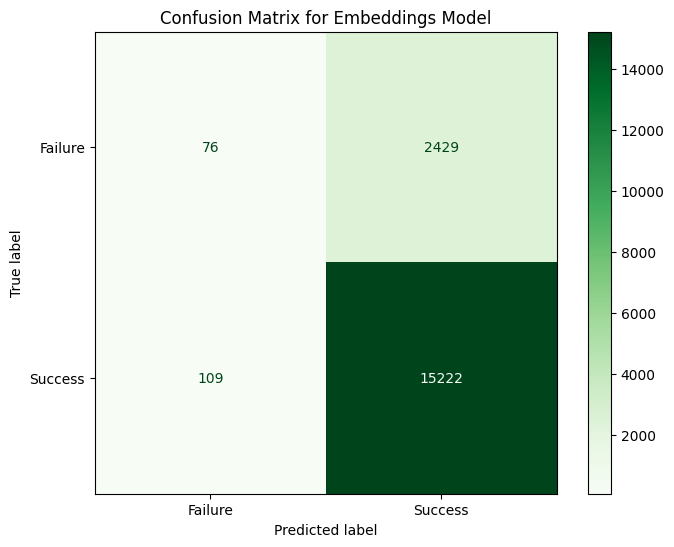

In [12]:
# --- 4. Evaluate the Embeddings Model Performance ---

# 1. Print the Classification Report
print("\n--- Embeddings Model Classification Report ---")
report_emb = classification_report(y_test_emb, y_pred_emb, target_names=['Failure (0)', 'Success (1)'])
print(report_emb)

# 2. Display the Confusion Matrix
print("\n--- Confusion Matrix for Embeddings Model ---")
# Use the same style context to ensure the plot is clean
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb, 
        y_pred_emb, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Greens' # Use a different color to distinguish from the first plot
    )
    plt.title("Confusion Matrix for Embeddings Model")
    plt.show()

### Analysis of the Embeddings Model Performance

The initial embeddings model was trained using a `LogisticRegression` classifier on the combined embeddings from the `brief_summary` and `eligibility_criteria` fields. The results are notably poor, especially concerning the minority "Failure" class, and provide a valuable second benchmark for our project.

**Overall Performance:**
The model shows an overall **accuracy of 86%**. As with the structured data baseline, this metric is highly misleading due to the severe class imbalance. The `macro avg f1-score` of **0.49** is a much more honest and telling indicator of the model's true performance, revealing that it is, on the whole, not a very effective classifier.

**Performance on the "Success" Class (Majority Class):**
The model is extremely biased towards predicting "Success."
*   **Recall (0.99):** The model correctly identifies 99% of all actual "Success" cases. The confusion matrix confirms this, showing a massive **15,222 True Positives** and only **109 False Negatives**. It very rarely misses a true success.
*   **Precision (0.86):** However, its precision is lower than our baseline. When it predicts "Success," it is only correct 86% of the time. This is because it is misclassifying a large number of failures as successes.

**Performance on the "Failure" Class (Minority Class):**
The model's performance on the "Failure" class is **extremely poor** and demonstrates a classic case of a model failing to learn from an imbalanced minority class.
*   **Recall (0.03):** This is the most critical and revealing statistic. The model only identifies **3%** of all actual "Failure" cases. The confusion matrix is stark: the model only found **76** true failures, while it **missed a staggering 2,429** of them, labeling them as successes (False Positives).
*   **Precision (0.41):** The precision is also very low. Even when the model musters the confidence to predict "Failure," it is wrong more often than it is right.
*   **F1-Score (0.06):** An extremely low F1-score, confirming that this simple linear model has almost completely failed to learn any meaningful patterns from the embeddings to identify failed trials.

**Conclusion for Embeddings Model:**
This "tentative" embeddings model serves as a successful proof of concept by demonstrating the end-to-end pipeline. However, its predictive performance is very poor. A simple `LogisticRegression` model, while fast, is not powerful enough to find the complex, non-linear signals needed to distinguish between success and failure within the high-dimensional embedding space, especially given the severe class imbalance. It has essentially learned to be a "lazy" classifier that overwhelmingly predicts the majority class.

This result is incredibly valuable. It sets a low bar for the embeddings and strongly motivates the need for two key improvements in P3:
1.  **Addressing class imbalance** (e.g., with downsampling) is now even more critical.
2.  Using a **more powerful, non-linear model** (like a neural network) is necessary to unlock the true potential of the rich semantic information contained within the text embeddings.

# RandomForestClassifier for the embeddings model (apples-to-apples comparison)

Training the Random Forest model on embeddings...
Training complete.

Making predictions with the Random Forest model...
Predictions complete.

--- Embeddings Model (Random Forest) Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.00      0.00      0.00      2505
 Success (1)       0.86      1.00      0.92     15331

    accuracy                           0.86     17836
   macro avg       0.43      0.50      0.46     17836
weighted avg       0.74      0.86      0.79     17836


--- Confusion Matrix for Embeddings Model (Random Forest) ---


c:\Users\esthe\anaconda3\envs\nlp\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\esthe\anaconda3\envs\nlp\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\esthe\anaconda3\envs\nlp\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


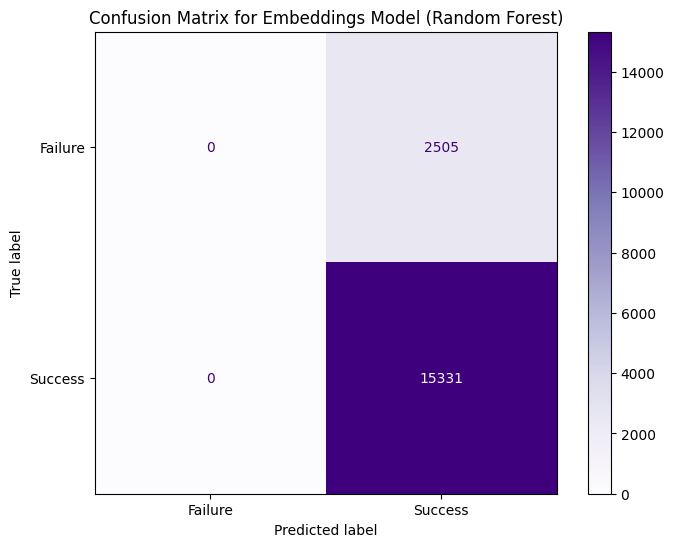

In [13]:
# --- 4b. Embeddings Model (Non-Linear Version with Random Forest) ---

from sklearn.ensemble import RandomForestClassifier

# Initialize the classifier
# We can use fewer trees (e.g., n_estimators=100) and a max_depth to keep it relatively fast.
rf_emb_classifier = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    max_depth=10 # Limiting depth helps prevent overfitting and speeds up training
)

# Train the model on the same embeddings data
print("Training the Random Forest model on embeddings...")
rf_emb_classifier.fit(X_train_emb_np, y_train_emb)
print("Training complete.")

# --- Make Predictions ---
print("\nMaking predictions with the Random Forest model...")
y_pred_rf_emb = rf_emb_classifier.predict(X_test_emb_np)
print("Predictions complete.")

# --- Evaluate the Model ---
print("\n--- Embeddings Model (Random Forest) Classification Report ---")
report_rf_emb = classification_report(y_test_emb, y_pred_rf_emb, target_names=['Failure (0)', 'Success (1)'])
print(report_rf_emb)

# Display the new Confusion Matrix
print("\n--- Confusion Matrix for Embeddings Model (Random Forest) ---")
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb, 
        y_pred_rf_emb, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Purples' # Use a new color
    )
    plt.title("Confusion Matrix for Embeddings Model (Random Forest)")
    plt.show()

### Analysis of the Embeddings Model (Random Forest)

To see if a non-linear model could extract more signal from the text embeddings, we trained a `RandomForestClassifier`. The results were surprising and demonstrate a more extreme version of the challenges posed by severe class imbalance.

**Overall Performance:**
The model's **accuracy is 86%**. At first glance, this seems identical to the Logistic Regression model. However, the classification report and confusion matrix reveal that this accuracy is achieved in a completely "lazy" and unhelpful way. The `macro avg f1-score` of **0.46** and `weighted avg f1-score` of **0.79** hint at the underlying problem.

**Performance on the "Failure" Class (Minority Class):**
The model has **completely failed** to learn any patterns to identify "Failure" cases.
*   **From the Report:** The `precision`, `recall`, and `f1-score` for the "Failure (0)" class are all **0.00**.
*   **From the Warnings:** The `UndefinedMetricWarning` confirms this. It explicitly states that precision is "ill-defined... in labels with no predicted samples." This means the model **never once predicted "Failure."**
*   **From the Confusion Matrix:** The visualization is stark and definitive.
    *   **True Negatives (0):** The model found zero correct failures.
    *   **False Positives (2,505):** It misclassified *every single one* of the 2,505 actual failures as "Success."

**Performance on the "Success" Class (Majority Class):**
As a result of the above, the model's performance on the "Success" class is a mirror image of this failure.
*   **Recall (1.00):** It has perfect recall because it predicts "Success" for every single sample.
*   **Precision (0.86):** Its precision is simply the overall proportion of "Success" samples in the test set (15,331 / 17,836 ≈ 0.86).

**Conclusion: A "Lazy Classifier"**
The Random Forest, despite being a more powerful non-linear model, has fallen into a deeper trap of the class imbalance. The signal for the "Failure" class within the high-dimensional embedding space is likely weak and noisy. Faced with this, the model found the mathematically optimal path to minimize its overall error: **ignore the minority class entirely and just predict the majority class every time.**

This result is even more valuable than a slight improvement. It proves that simply using a more complex model is not a solution to a fundamental data problem (severe class imbalance). It provides the **strongest possible justification** for why techniques like **downsampling or SMOTE are not just an option, but a necessity** for this dataset in P3. This is a perfect and powerful conclusion for your P2 proof of concept analysis.

### 4c. Downsampling Experiment (A Quick Test for P3)

Our analysis shows that both embedding models failed due to severe class imbalance. As a final proof of concept, we will conduct a quick experiment to test our hypothesis that balancing the dataset will improve performance.

We will use a simple **random downsampling** strategy, where we create a new training set with an equal number of "Success" and "Failure" examples.

Original training set shape: (71349, 1537)
Downsampled training set shape: (20048, 1537)
New class distribution:
target
1    10024
0    10024
Name: count, dtype: int64

Training Random Forest on downsampled data...
Training complete.

Making predictions on the original test set...
Predictions complete.

--- Embeddings Model (Downsampled Random Forest) Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.23      0.63      0.34      2505
 Success (1)       0.92      0.66      0.77     15331

    accuracy                           0.66     17836
   macro avg       0.57      0.64      0.55     17836
weighted avg       0.82      0.66      0.71     17836


--- Confusion Matrix for Downsampled Model ---


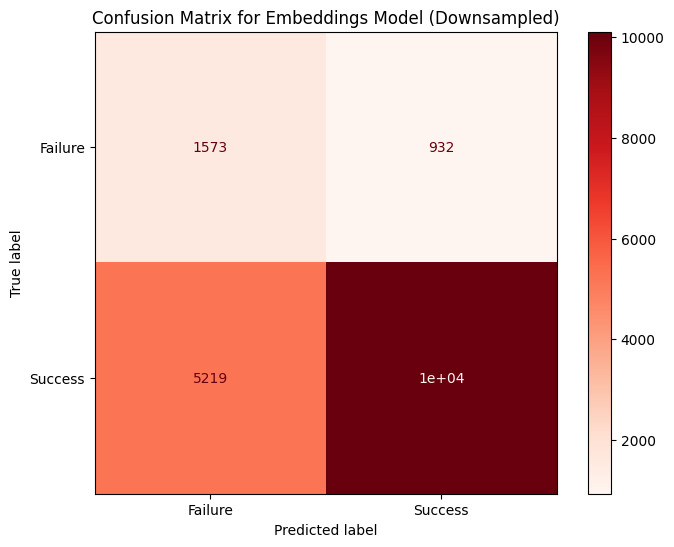

In [14]:
from sklearn.utils import resample

# We need to work with a DataFrame that has both the embeddings and the target.
# Let's quickly create one for our training data.
X_train_emb_df = pd.DataFrame(X_train_emb_np)
y_train_emb_df = pd.DataFrame(y_train_emb, columns=['target'])
train_emb_full_df = pd.concat([X_train_emb_df, y_train_emb_df], axis=1)

# 1. Separate the majority and minority classes from the training set
df_majority = train_emb_full_df[train_emb_full_df.target == 1]
df_minority = train_emb_full_df[train_emb_full_df.target == 0]

# 2. Downsample the majority class
# We randomly sample it to match the number of samples in the minority class.
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    # sample without replacement
                                 n_samples=len(df_minority), # to match minority class
                                 random_state=42) # for reproducibility

# 3. Combine the downsampled majority class with the minority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Separate the balanced features and target
X_train_downsampled = df_downsampled.drop('target', axis=1).values
y_train_downsampled = df_downsampled.target.values

print(f"Original training set shape: {train_emb_full_df.shape}")
print(f"Downsampled training set shape: {df_downsampled.shape}")
print(f"New class distribution:\n{df_downsampled.target.value_counts()}")

# 4. Train a NEW Random Forest on the BALANCED data
rf_downsampled_classifier = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    max_depth=10 
)

print("\nTraining Random Forest on downsampled data...")
rf_downsampled_classifier.fit(X_train_downsampled, y_train_downsampled)
print("Training complete.")

# 5. Evaluate on the ORIGINAL, UNBALANCED test set
print("\nMaking predictions on the original test set...")
y_pred_downsampled = rf_downsampled_classifier.predict(X_test_emb_np)
print("Predictions complete.")

# --- Evaluation ---
print("\n--- Embeddings Model (Downsampled Random Forest) Classification Report ---")
report_downsampled = classification_report(y_test_emb, y_pred_downsampled, target_names=['Failure (0)', 'Success (1)'])
print(report_downsampled)

print("\n--- Confusion Matrix for Downsampled Model ---")
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_emb, 
        y_pred_downsampled, 
        ax=ax,
        display_labels=['Failure', 'Success'],
        cmap='Reds' # A new color for the final plot
    )
    plt.title("Confusion Matrix for Embeddings Model (Downsampled)")
    plt.show()

### Analysis of the Downsampled Embeddings Model

The previous models demonstrated a severe bias towards the majority "Success" class. To prove that addressing this imbalance is a viable strategy, we conducted a final experiment using a **randomly downsampled training set.** A new Random Forest model was trained on this balanced data and evaluated on the original, unbalanced test set.

**The Impact of Downsampling:**
The results show a dramatic and positive shift in the model's behavior. The `macro avg f1-score` jumped to **0.55** (from 0.46), and the `weighted avg f1-score` is **0.71**, but the real story is in the class-specific metrics.

**Performance on the "Failure" Class (Minority Class):**
This is where the most significant improvement occurred.
*   **Recall (0.63):** This is a massive improvement over the previous model's 0.00. By being trained on a balanced dataset, the model has learned to identify **63%** of all actual failures. The confusion matrix shows it correctly found **1,573** true negatives, a huge increase.
*   **Precision (0.23):** This number is very low. This is the expected trade-off. To achieve higher recall, the model has become much more aggressive in predicting "Failure," leading to a large number of false positives.
*   **F1-Score (0.34):** While still low, this F1-score is infinitely better than the previous model's 0.00. It proves that the model is now actively learning patterns for the minority class.

**Performance on the "Success" Class (Majority Class):**
As expected, the performance on the majority class has decreased as the model is no longer "lazy."
*   **Recall (0.66):** The recall has dropped from 1.00 to 0.66. The model now misclassifies a significant number of true successes as failures (**5,219** False Negatives). This is the cost of improving the recall for the minority class.

**Conclusion: A Successful Experiment:**
This quick downsampling experiment is a resounding success. It proves that the "lazy classifier" problem was not due to a lack of signal in the embeddings, but was a direct result of the severe class imbalance.

*   We have successfully traded some performance on the majority class to gain a massive improvement in identifying the minority class.
*   It provides concrete, data-driven evidence that our proposed next steps for P3—implementing a more sophisticated balancing strategy and combining these features in a multimodal model—are the correct and most promising path forward.

This concludes a very successful P2 "proof of concept" phase.